     ┌──────┐
q_0: ┤0     ├
     │      │
q_1: ┤1 QFT ├
     │      │
q_2: ┤2     ├
     └──────┘


C:\Users\petph\AppData\Local\Temp\ipykernel_31468\1746387821.py:9: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(num_qubits=n) # note: replace with QFTGate later


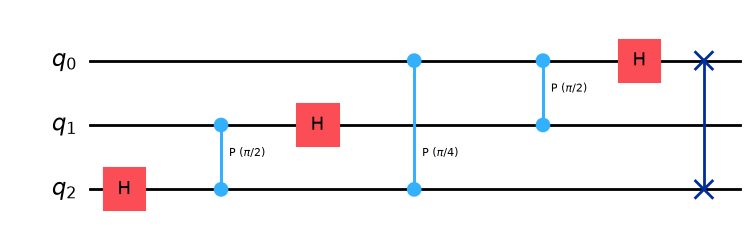

In [4]:
# part 4 - quantum fourier transform
# essentially is the quantum version of the classic fourier transform

# Install if needed
# !pip install qiskit

from qiskit.circuit.library import QFT

n = 3
qft = QFT(num_qubits=n) # note: replace with QFTGate later

print(qft)
qft.decompose().draw(output='mpl', style='iqp')

Statevector([ 3.53553391e-01+0.j        , -2.50000000e-01-0.25j      ,
              2.16489014e-17+0.35355339j,  2.50000000e-01-0.25j      ,
             -3.53553391e-01+0.j        ,  2.50000000e-01+0.25j      ,
             -2.16489014e-17-0.35355339j, -2.50000000e-01+0.25j      ],
            dims=(2, 2, 2))


C:\Users\petph\AppData\Local\Temp\ipykernel_31468\2906178075.py:13: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(QFT(n), inplace=True)


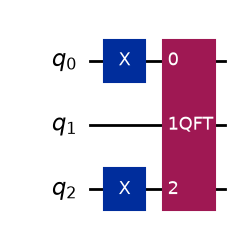

In [8]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT

n = 3
qc = QuantumCircuit(n)

# Prepare |101>
qc.x(0)
qc.x(2)

# Apply QFT
qc.compose(QFT(n), inplace=True)

state = Statevector.from_instruction(qc)
print(state)
qc.draw(output='mpl', style='iqp')

In [12]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT

n = 3
qc = QuantumCircuit(n)
qc.h(range(n))

qc.compose(QFT(n), inplace=True)
qc.compose(QFT(n, inverse=True), inplace=True)

state = Statevector.from_instruction(qc)
print(state)

Statevector([0.35355339+6.40074376e-35j, 0.35355339+1.44924671e-34j,
             0.35355339-5.05347085e-35j, 0.35355339-1.31451942e-34j,
             0.35355339+5.85204936e-35j, 0.35355339+1.44924671e-34j,
             0.35355339-7.19932227e-35j, 0.35355339-1.58397400e-34j],
            dims=(2, 2, 2))


C:\Users\petph\AppData\Local\Temp\ipykernel_31468\1790315009.py:9: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(QFT(n), inplace=True)
C:\Users\petph\AppData\Local\Temp\ipykernel_31468\1790315009.py:10: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(QFT(n, inverse=True), inplace=True)


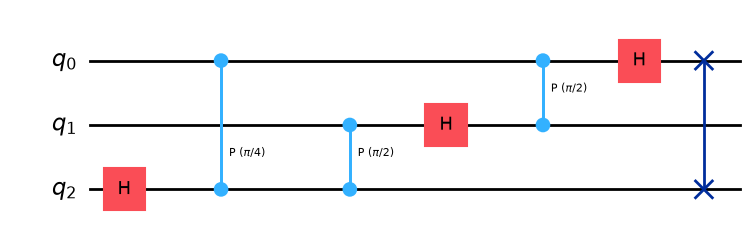

In [13]:
from qiskit import QuantumCircuit
import numpy as np


def qft_rotations(circuit, n):
    if n == 0:
        return

    n -= 1
    circuit.h(n)

    for qubit in range(n):
        angle = np.pi / (2 ** (n - qubit))
        circuit.cp(angle, qubit, n)

    qft_rotations(circuit, n)


def swap_registers(circuit, n):
    for qubit in range(n // 2):
        circuit.swap(qubit, n - qubit - 1)


def qft(circuit, n):
    qft_rotations(circuit, n)
    swap_registers(circuit, n)


n = 3
qc = QuantumCircuit(n)
qft(qc, n)
qc.draw(output='mpl', style='iqp')

C:\Users\petph\AppData\Local\Temp\ipykernel_31468\661835721.py:4: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  approx_qft = QFT(num_qubits=5, approximation_degree=2)


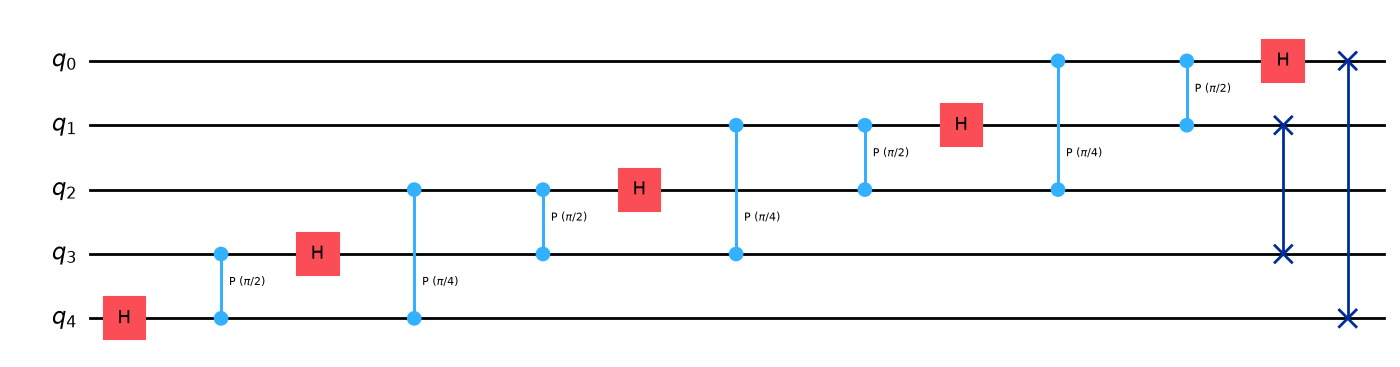

In [16]:
# approx variant, reduce circuit depth
from qiskit.circuit.library import QFT

approx_qft = QFT(num_qubits=5, approximation_degree=2)
approx_qft.decompose().draw(output='mpl', style='iqp')

Initial circuit:


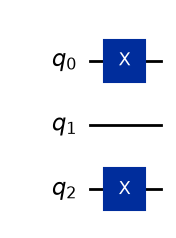

Initial statevector:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))
Circuit after QFT:


C:\Users\petph\AppData\Local\Temp\ipykernel_31468\3043993078.py:31: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_circuit = QFT(num_qubits=n)


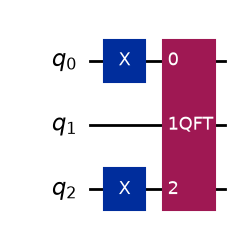

Statevector after QFT:
Statevector([ 3.53553391e-01+0.j        , -2.50000000e-01-0.25j      ,
              2.16489014e-17+0.35355339j,  2.50000000e-01-0.25j      ,
             -3.53553391e-01+0.j        ,  2.50000000e-01+0.25j      ,
             -2.16489014e-17-0.35355339j, -2.50000000e-01+0.25j      ],
            dims=(2, 2, 2))
Recovered state after QFT followed by inverse QFT:
Statevector([ 1.55582133e-19-1.13411537e-17j,
             -5.48888227e-17+0.00000000e+00j,
              1.55582133e-19+1.13411537e-17j,
              4.76210391e-18+3.11164266e-19j,
              1.55582133e-19+1.16523180e-17j,
              1.00000000e+00+0.00000000e+00j,
              1.55582133e-19-1.16523180e-17j,
              4.76210391e-18-3.11164266e-19j],
            dims=(2, 2, 2))
Approximate QFT circuit:


C:\Users\petph\AppData\Local\Temp\ipykernel_31468\3043993078.py:47: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_inverse.compose(QFT(num_qubits=n, inverse=True), inplace=True)
C:\Users\petph\AppData\Local\Temp\ipykernel_31468\3043993078.py:57: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  approx_qft = QFT(num_qubits=5, approximation_degree=2)


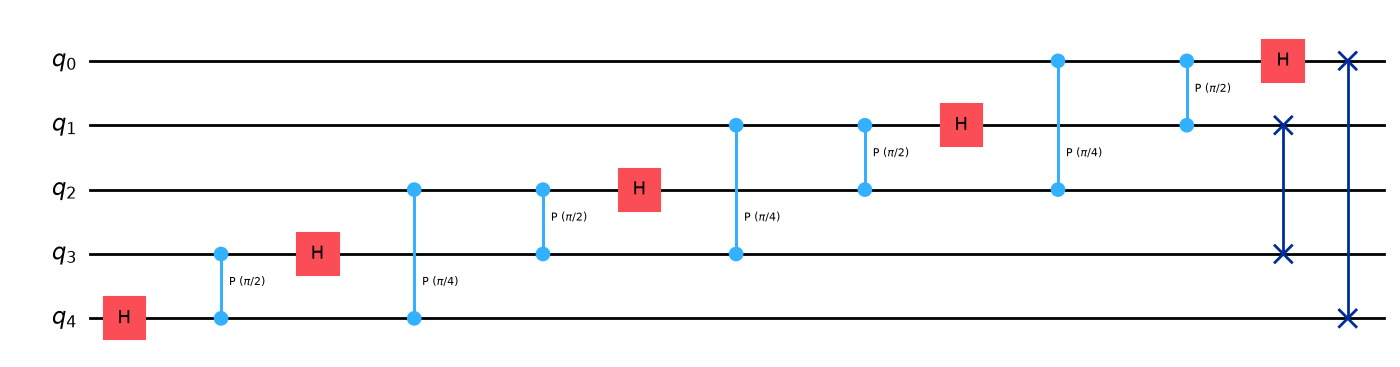

Manual QFT circuit:


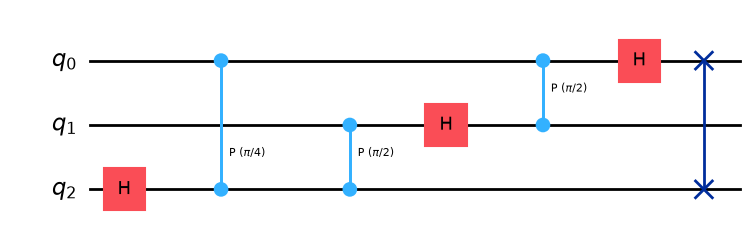

In [17]:
# Full code: Quantum Fourier Transform (QFT)

# If needed:
# !pip install qiskit numpy

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT

# --------------------------------------------------
# 1. Create a 3-qubit basis state |101>
# --------------------------------------------------

n = 3
qc = QuantumCircuit(n)
qc.x(0)
qc.x(2)

print('Initial circuit:')
display(qc.draw(output='mpl', style='iqp'))

initial_state = Statevector.from_instruction(qc)
print('Initial statevector:')
print(initial_state)

# --------------------------------------------------
# 2. Apply QFT
# --------------------------------------------------

qft_circuit = QFT(num_qubits=n)
qc_qft = qc.copy()
qc_qft.compose(qft_circuit, inplace=True)

print('Circuit after QFT:')
display(qc_qft.draw(output='mpl', style='iqp'))

qft_state = Statevector.from_instruction(qc_qft)
print('Statevector after QFT:')
print(qft_state)

# --------------------------------------------------
# 3. Apply inverse QFT
# --------------------------------------------------

qc_inverse = qc_qft.copy()
qc_inverse.compose(QFT(num_qubits=n, inverse=True), inplace=True)

recovered_state = Statevector.from_instruction(qc_inverse)
print('Recovered state after QFT followed by inverse QFT:')
print(recovered_state)

# --------------------------------------------------
# 4. Approximate QFT
# --------------------------------------------------

approx_qft = QFT(num_qubits=5, approximation_degree=2)
print('Approximate QFT circuit:')
display(approx_qft.decompose().draw(output='mpl', style='iqp'))

# --------------------------------------------------
# 5. Manual implementation
# --------------------------------------------------


def qft_rotations(circuit, n):
    if n == 0:
        return

    n -= 1
    circuit.h(n)

    for qubit in range(n):
        angle = np.pi / (2 ** (n - qubit))
        circuit.cp(angle, qubit, n)

    qft_rotations(circuit, n)


def swap_registers(circuit, n):
    for qubit in range(n // 2):
        circuit.swap(qubit, n - qubit - 1)


def qft_manual(circuit, n):
    qft_rotations(circuit, n)
    swap_registers(circuit, n)


manual_circuit = QuantumCircuit(3)
qft_manual(manual_circuit, 3)

print('Manual QFT circuit:')
display(manual_circuit.draw(output='mpl', style='iqp'))